## Dealing With Discrete Priors

According to what's been mentioned in the project file, we are supposed to assume that $\theta$ is discrete (even though it's a rather unrealistic assumption in my opinion) and can only take 10 possible different values:

$$ \theta = \{ 0.1, 0.2, \cdots,  1\} $$

To initiate our bayesian investigations, we first need to choose an appropriate **prior**. In this particular case, it simply means to define a pmf for $\theta$ based on our intuition and guesswork (maybe). Here's the prior distribution for the random variable $\theta$ according to the file:

$$
\pi_{\text{Ghader}}(\theta) = 
\begin{cases}
0.05, & \text{if } \theta = 0.1, 0.2 \\
0.10, & \text{if } \theta = 0.3, 0.4 \\
0.20, & \text{if } \theta = 0.5, 0.6 \\
0.10, & \text{if } \theta = 0.7, 0.8 \\
0.05, & \text{if } \theta = 0.9, 1.0 \\
\end{cases}
$$

This shows our degree of belief in each possible value of $\theta$ before any real data is observed. What we are aiming for is to readjust this pmf such that it fits our observations more closely. In other words, we wanna find out which values of $\theta$ are the most probable.

### The Likelihood Function

According to the file, we have observed 12 "yes"es out of 20 individuals surveyed. Thus, we know our likelihood function is:

$$ \mathcal{L}(\theta)=\binom{20}{12}(\theta)^{12}(1-\theta)^8 $$

(It's just the binomial pmf expressed as a function of $\theta$ instead of number of successes)

Now its the time to calculate the posterior distribution according to the Baye's Theorem:

### Implementation:

In [1]:
import math
import pandas as pd

precomputed_binom_coefficient = math.comb(20, 12) # precompute binomial coefficient for optimization

prior_df = pd.DataFrame({
    'theta': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'prior_pmf': [0.05, 0.05, 0.10, 0.10, 0.20, 0.20, 0.10, 0.10, 0.05, 0.05]
})

def likelihood(theta):
    return precomputed_binom_coefficient * (theta ** 12) * ((1 - theta) ** 8)

# Calculate unnormalized posteriors
prior_df['likelihood'] = prior_df['theta'].apply(likelihood)
prior_df['unnormalized_posterior'] = prior_df['prior_pmf'] * prior_df['likelihood']

# Normalize to get posterior PMF
total_probability = prior_df['unnormalized_posterior'].sum()
prior_df['posterior_pmf'] = prior_df['unnormalized_posterior'] / total_probability

prior_df.round(6)

,theta,prior_pmf,likelihood,unnormalized_posterior,posterior_pmf
0,0.1,0.05,0.000000,0.000000,0.000000
1,0.2,0.05,0.000087,0.000004,0.000056
2,0.3,0.10,0.003859,0.000386,0.004974
3,0.4,0.10,0.035497,0.003550,0.045755
4,0.5,0.20,0.120134,0.024027,0.309698
5,0.6,0.20,0.179706,0.035941,0.463269
6,0.7,0.10,0.114397,0.011440,0.147453
7,0.8,0.10,0.022161,0.002216,0.028565
8,0.9,0.05,0.000356,0.000018,0.000229
9,1.0,0.05,0.000000,0.000000,0.000000


### Answer to the questions (according to the results)

1. the most likely value of $\theta$ in prior distribution: 0.5 & 0.6
2. the most likely value of $\theta$ in posterior distribution: 0.6
3. $P(\theta \gt 0.5) = \sum_{i=6}^{10}{P(\theta=i/10)} = 0.639516$

## Continious Prior

Now, let's use a continious prior distribution for $\theta$ instead and see how we can derive the posterior distribution.

The process is still the same as before. We just need to evaluate this expression:

$$
P(\theta = x | data) = \frac{P(data | \theta = x).P(\theta = x)}{\int_{0}^{1}P(data|\theta=x)P(\theta = x)dx}
$$

### Flat Prior

Let's choose a flat prior for now. Something like $Beta(1,1)$ which is equivalent to $\text{Uniform}(0,1)$. Then we'll have:
- $P(\theta = x) = f_{\theta}(x) = \frac{1}{1-0} = 1$
- $P(data | \theta = x) = \binom{20}{12}(x)^{12}(1 - x)^8$

By substituting them into the original expression we arrive at:

$$
\begin{align*}
P(\theta = x | data) &= \frac{\binom{20}{12}(x)^{12}(1 - x)^8}{\int_{0}^{1}\binom{20}{12}(x)^{12}(1 - x)^8dx} \\
&= \frac{(x)^{12}(1 - x)^8}{\int_{0}^{1}(x)^{12}(1 - x)^8dx} \\
&= \frac{(x)^{12}(1 - x)^8}{\Beta(13,9)}
\end{align*}
$$

Which reveals that $\theta|data \sim \text{Beta}(13,9)$

### Skewed Prior

By repeating the same process for skewed distributions we obtain:
- Right-Skewed Beta Distribution: $\theta \sim \text{Beta}(2,5) \implies \theta|data \sim \text{Beta}(14,13)$
- Left-Skewed Beta Distribution: $\theta \sim \text{Beta}(5,2) \implies \theta|data \sim \text{Beta}(17,10)$

### Finding The Mode


The PDF of the Beta distribution $\text{Beta}(\alpha, \beta)$ is:

$$
f(x) = \frac{1}{B(\alpha, \beta)} x^{\alpha - 1} (1 - x)^{\beta - 1}, \quad \text{for } x \in (0, 1)
$$

Since $B(\alpha, \beta)$ is just a constant, we ignore it and instead maximize:

$$
g(x) = x^{\alpha - 1}(1 - x)^{\beta - 1}
$$

Let:

$$
\log g(x) = (\alpha - 1)\log x + (\beta - 1)\log(1 - x)
$$

Differentiate with respect to $x$ in order to find the critical points:

$$
\frac{d}{dx} \log g(x) = \frac{\alpha - 1}{x} - \frac{\beta - 1}{1 - x}
$$

Set derivative to zero:

$$
\frac{\alpha - 1}{x} = \frac{\beta - 1}{1 - x}
$$

Now we just need to solve for x:

$$
x = \frac{\alpha - 1}{\alpha + \beta - 2}
$$

It's worth noting that this formula only holds true when $\alpha,\beta>1$, here are the other edge cases (although we don't need them):

- If $\alpha < 1$ and $\beta > 1$: mode is at $x = 0$
- If $\alpha > 1$ and $\beta < 1$: mode is at $x = 1$
- If $\alpha < 1$ and $\beta < 1$: we have two modes at both ends: $x = 0$ and $x = 1$

According to the aforementioned formula:
- Flat: $\theta \sim \text{Beta}(1,1) \implies \theta|data \sim \text{Beta}(13,9) \implies mode=\frac{12}{20}$
- Right-Skewed: $\theta \sim \text{Beta}(2,5) \implies \theta|data \sim \text{Beta}(14,13) \implies mode=\frac{13}{25}$
- Left-Skewed: $\theta \sim \text{Beta}(5,2) \implies \theta|data \sim \text{Beta}(17,10) \implies mode=\frac{16}{25}$

### Calculating $P(\theta > 0.5 | data)$

For each of the posterior distributions, we need to calculate $\int_{0.5}^{1}f(\theta|data)d\theta$:



In [2]:
import pandas as pd
from scipy.special import betainc as beta_CDF


flat_params = 13,9
right_skewed_params = 14,13
left_skewed_params = 17,10

p1 = 1 - beta_CDF(*flat_params, .5)
p2 = 1 - beta_CDF(*right_skewed_params, .5)
p3 = 1 - beta_CDF(*left_skewed_params, .5)

pd.DataFrame([[p1,p2,p3]], columns=['p1', 'p2', 'p3'])

,p1,p2,p3
0,0.808345,0.577491,0.915681


### Finding The 95% Credible Interval

To accomplish this task we need to find the 2.5th and 97.5th percentile of a large-enough sample produced from our posterior distros:

In [3]:
import numpy as np
import pandas as pd

flat_sample = np.random.beta(13,9,size=100000)
right_skewed_sample = np.random.beta(14,13,size=100000)
left_skewed_sample = np.random.beta(17,10,size=100000)


flat_bounds = np.percentile(flat_sample, 2.5), np.percentile(flat_sample, 97.5)
right_skewed_bounds = np.percentile(right_skewed_sample, 2.5), np.percentile(right_skewed_sample, 97.5)
left_skewed_bounds = np.percentile(left_skewed_sample, 2.5), np.percentile(left_skewed_sample, 97.5)


rounded_row = [tuple(round(x, 3) for x in pair) for pair in [flat_bounds, right_skewed_bounds, left_skewed_bounds]]

pd.DataFrame([rounded_row], columns=['flat 95% CI', 'right skewed 95% CI', 'left skewed 95% CI'])

,flat 95% CI,right skewed 95% CI,left skewed 95% CI
0,"(0.385, 0.782)","(0.333, 0.7)","(0.442, 0.798)"


### Distribution Graphs And Illustrations

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

def plot_beta_distribution(title, a, b):
    x = np.linspace(0, 1, 1000)
    y = beta.pdf(x, a, b)

    mode = (a - 1) / (a + b - 2)

    # Create plot
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, label=f'Beta PDF (a={a}, b={b})', color='blue')

    # Shade area where x > 0.5
    x_fill = x[x > 0.5]
    y_fill = y[x > 0.5]
    plt.fill_between(x_fill, y_fill, alpha=0.3, color='green', label='P(X > 0.5)')

    # Plot mode line
    plt.axvline(mode, color='red', linestyle='--', label=f'Mode = {mode:.2f}')

    # Styling
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    return plt


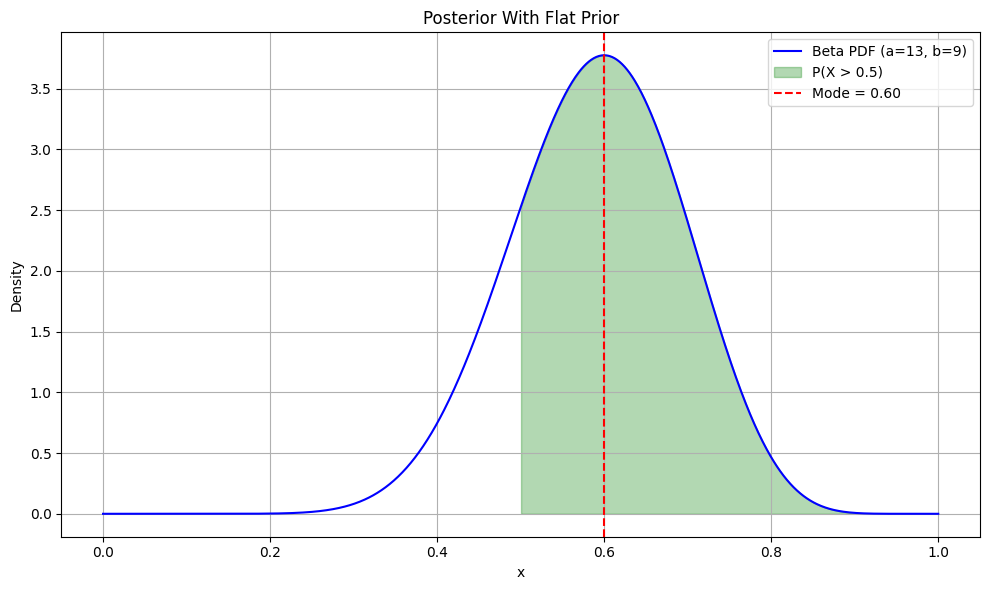

In [22]:
plt = plot_beta_distribution('Posterior With Flat Prior', *flat_params)
plt.show()

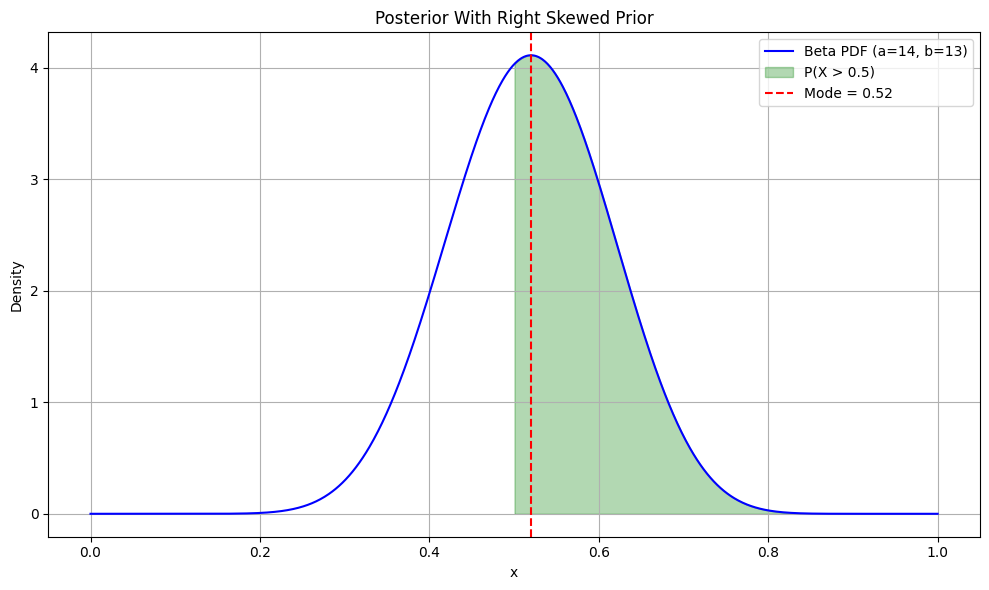

In [23]:
plt = plot_beta_distribution('Posterior With Right Skewed Prior',*right_skewed_params)
plt.show()

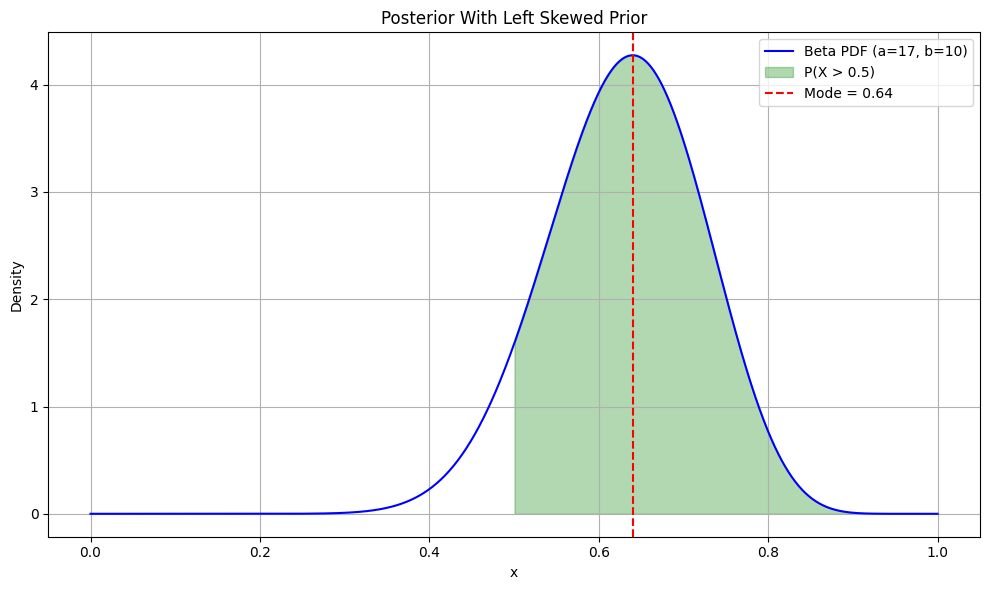

In [24]:
plt = plot_beta_distribution('Posterior With Left Skewed Prior', *left_skewed_params)
plt.show()

## Posterior Predictive Distribution

In this section, we are asked to repeat the same experiment with a larger sample size (n=500) and predict what happens. This can be done by averaging over all possible values of theta weighting each value based on how probable that particular value of theta is according to the posterior distribution.

For this part, we've chosen the posterior obtained from left-skewed prior.

### Deriving The Posterior Predictive Distribution Analytically

$$
\begin{align*}
P(\tilde{Y}=y|Y) &= \int_{0}^{1} P(\tilde{Y}=y | \theta=x).P(\theta=x | Y) \\
&= \int_{0}^{1} \binom{500}{y}x^{y}(1-x)^{500-y}.\frac{1}{\Beta(17,10)}x^{16}(1-x)^9dx \\
&= \binom{500}{y}.\frac{\Beta(y+16, 509-y)}{\Beta(17,10)}
\end{align*}
$$

This means $\tilde{Y} | Y \sim BetaBinom(n=500, \alpha=17, \beta=10)$

#### Distribution Graph:

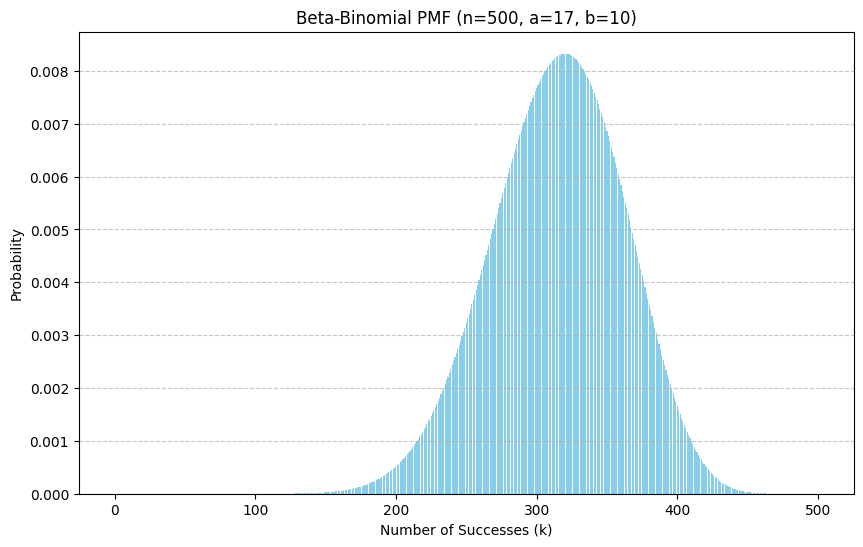

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import betabinom


n = 500
a = 17 # Alpha parameter of the Beta distribution
b = 10 # Beta parameter of the Beta distribution
k = np.arange(n + 1)

pmf = betabinom.pmf(k, n, a, b)
plt.figure(figsize=(10, 6))
plt.bar(k, pmf, color='skyblue')
plt.xlabel('Number of Successes (k)')
plt.ylabel('Probability')
plt.title(f'Beta-Binomial PMF (n={n}, a={a}, b={b})')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()